In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.manifold import TSNE
import umap
import trimap
import pacmap

import warnings

warnings.filterwarnings('ignore')

RANDOM_STATE = 318

In [22]:
df = pd.read_csv("soybean-large.data", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,diaporthe-stem-canker,6,0,2,1,0,1,1,1,0,...,0,0,0,4,0,0,0,0,0,0
1,diaporthe-stem-canker,4,0,2,1,0,2,0,2,1,...,0,0,0,4,0,0,0,0,0,0
2,diaporthe-stem-canker,3,0,2,1,0,1,0,2,1,...,0,0,0,4,0,0,0,0,0,0
3,diaporthe-stem-canker,3,0,2,1,0,1,0,2,0,...,0,0,0,4,0,0,0,0,0,0
4,diaporthe-stem-canker,6,0,2,1,0,2,0,1,0,...,0,0,0,4,0,0,0,0,0,0


In [23]:
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

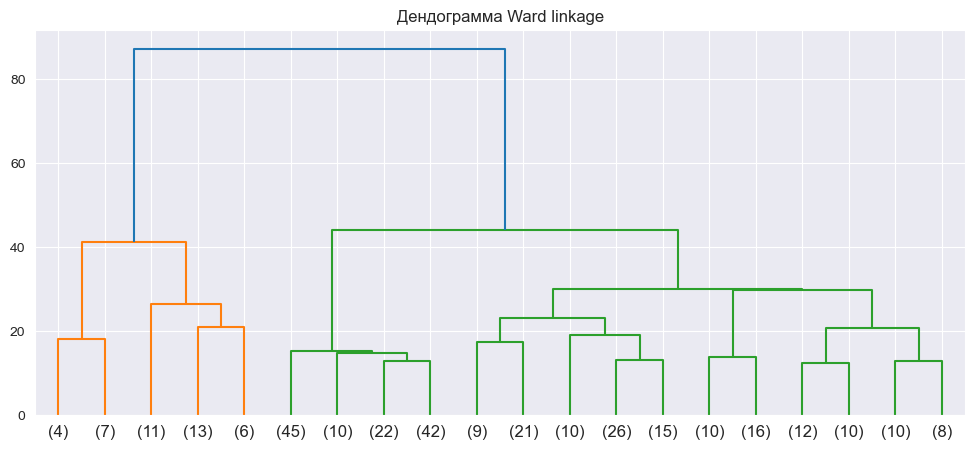

In [24]:
link = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(link, truncate_mode='lastp', p=20)
plt.title("Дендограмма Ward linkage")
plt.show()

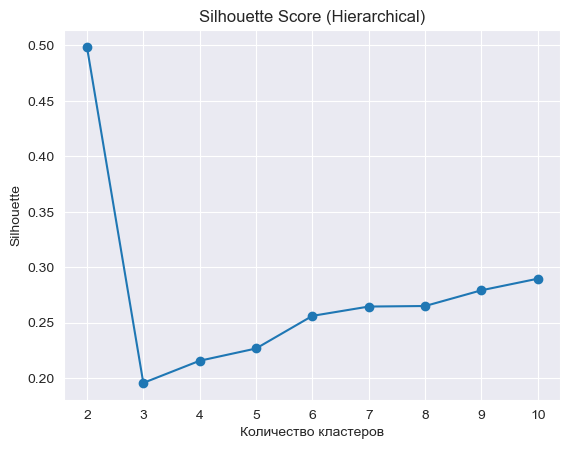

np.int64(2)

In [25]:
silh_scores = []
for k in range(2, 11):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_scaled)
    silh_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), silh_scores, marker='o')
plt.title("Silhouette Score (Hierarchical)")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

best_k_h = np.argmax(silh_scores) + 2
best_k_h

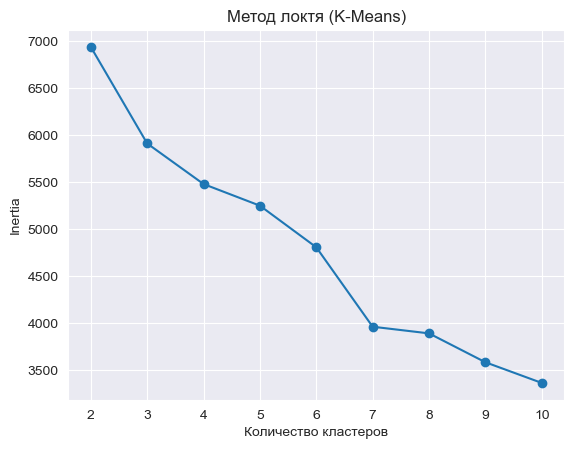

In [26]:
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2, 11), inertias, marker='o')
plt.title("Метод локтя (K-Means)")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

best_k_km = 4

In [27]:
hier = AgglomerativeClustering(n_clusters=best_k_h)
hier_labels = hier.fit_predict(X_scaled)

km = KMeans(n_clusters=best_k_km, random_state=RANDOM_STATE)
km_labels = km.fit_predict(X_scaled)

print("Hierarchical silhouette:", silhouette_score(X_scaled, hier_labels))
print("KMeans silhouette:", silhouette_score(X_scaled, km_labels))
print("ARI Hierarchical:", adjusted_rand_score(y, hier_labels))
print("ARI KMeans:", adjusted_rand_score(y, km_labels))

Hierarchical silhouette: 0.4985738670515118
KMeans silhouette: 0.18404914140248804
ARI Hierarchical: 0.8805647458461664
ARI KMeans: 0.20409711737609218


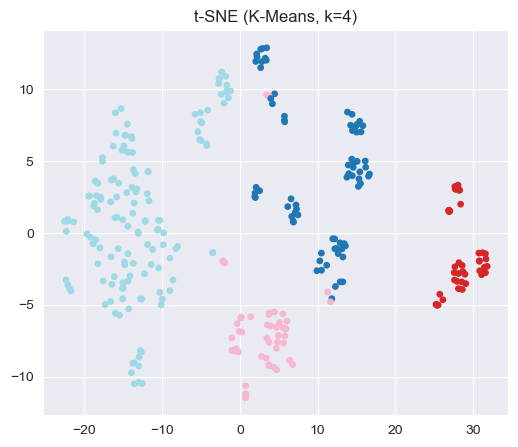

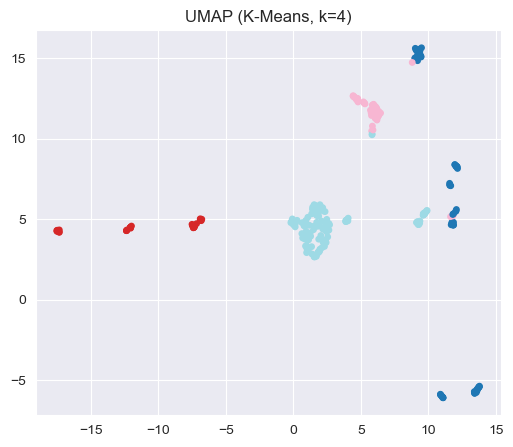

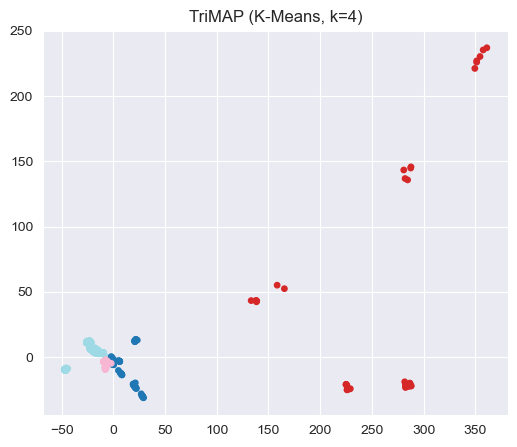

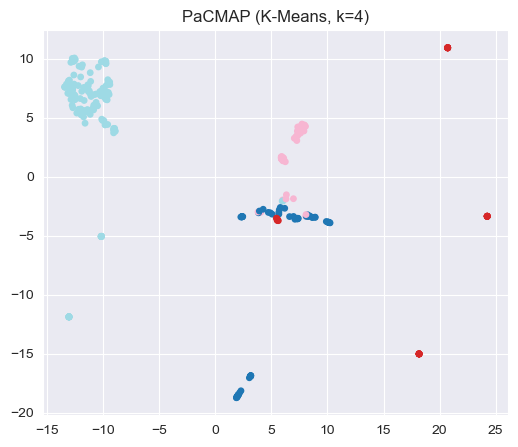

In [28]:
methods = {
    "t-SNE": TSNE(n_components=2, random_state=RANDOM_STATE),
    "UMAP": umap.UMAP(random_state=RANDOM_STATE),
    "TriMAP": trimap.TRIMAP(n_random=RANDOM_STATE),
    "PaCMAP": pacmap.PaCMAP(random_state=RANDOM_STATE)
}

for name, reducer in methods.items():
    embedding = reducer.fit_transform(X_scaled)
    plt.figure(figsize=(6, 5))
    plt.scatter(embedding[:,0], embedding[:,1], c=km_labels, cmap='tab20', s=15)
    plt.title(f"{name} (K-Means, k={best_k_km})")
    plt.show()

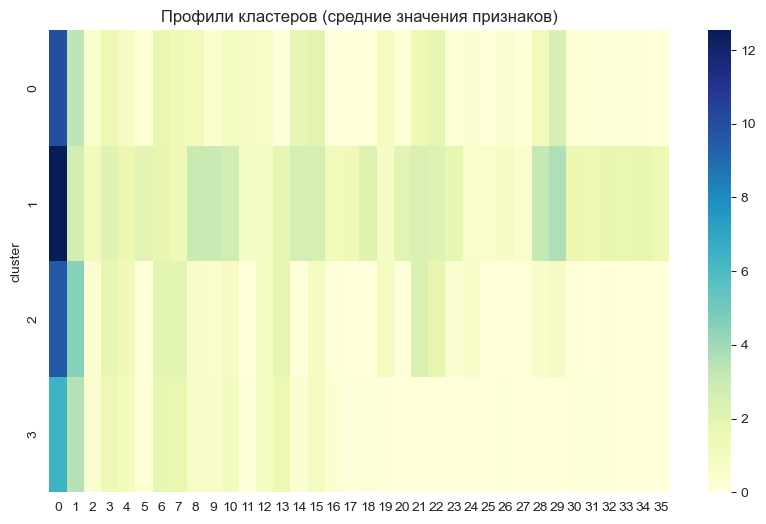

In [29]:
df_km = df.copy()
df_km["cluster"] = km_labels

cluster_profile = df_km.groupby("cluster").mean()
plt.figure(figsize=(10,6))
sns.heatmap(cluster_profile, cmap="YlGnBu")
plt.title("Профили кластеров (средние значения признаков)")
plt.show()

In [30]:
print(f"Лучшее число кластеров по Silhouette: {best_k_h}")
print(f"Лучшее число кластеров по elbow: {best_k_km}")
print("По показателям Silhouette и ARI алгоритм K-Means показывает более устойчивое разделение.")

Лучшее число кластеров по Silhouette: 2
Лучшее число кластеров по elbow: 4
По показателям Silhouette и ARI алгоритм K-Means показывает более устойчивое разделение.
